# Phase 5 — Predictive Model for Final 3 & 5 Minute Scoring

Building on the driver analysis from notebook 04, this notebook:
1. Prepares a **game-level feature matrix** using the 7 key drivers
2. Trains and evaluates **multiple models** (Ridge, Random Forest, Gradient Boosting, XGBoost)
3. Validates predictions against **real game data**

### Key Features (ordered by importance)
1. **Point differential** (bucketed in 3's) — most important
2. **Adj. defensive efficiency** (leading team)
3. **Adj. offensive efficiency** (leading & trailing teams)
4. **Pace** (leading team)
5. **3P%** (trailing team)
6. **ORB rankings** (leading team)
7. **Home / away status** (leading team)

---

## 0 — Setup & Load Data

In [1]:
import pandas as pd
import pyarrow.parquet as pq
import numpy as np
import matplotlib.pyplot as plt
import os, warnings

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('XGBoost not installed — will skip XGB model')

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

# ── Style ──
plt.rcParams.update({
    'figure.facecolor': '#1a1a2e', 'axes.facecolor': '#16213e',
    'axes.edgecolor': '#e0e0e0', 'axes.labelcolor': '#e0e0e0',
    'text.color': '#e0e0e0', 'xtick.color': '#e0e0e0', 'ytick.color': '#e0e0e0',
    'font.size': 11, 'axes.titlesize': 14, 'figure.titlesize': 16,
})

SEASON = 2024
DATA_DIR = os.path.join(os.getcwd(), 'data')

pbp      = pq.read_table(os.path.join(DATA_DIR, f'pbp_{SEASON}.parquet')).to_pandas()
team_box = pq.read_table(os.path.join(DATA_DIR, f'team_box_{SEASON}.parquet')).to_pandas()
schedule = pq.read_table(os.path.join(DATA_DIR, f'schedule_{SEASON}.parquet')).to_pandas()

print(f'PBP: {pbp.shape[0]:,} rows ({pbp["game_id"].nunique():,} games)')
print(f'Team Box: {team_box.shape[0]:,} rows')
print(f'Schedule: {schedule.shape[0]:,} rows')

# ── Fine-grained margin buckets (3-point intervals) ──
FINE_LABELS = ['0 (Tied)', '1-3', '4-6', '7-9', '10-12', '13-15', '16-18', '19+']

def fine_bucket(m):
    m = int(abs(m))
    if   m == 0:        return '0 (Tied)'
    elif m <= 3:        return '1-3'
    elif m <= 6:        return '4-6'
    elif m <= 9:        return '7-9'
    elif m <= 12:       return '10-12'
    elif m <= 15:       return '13-15'
    elif m <= 18:       return '16-18'
    else:               return '19+'

PBP: 2,004,997 rows (6,151 games)
Team Box: 12,480 rows
Schedule: 6,249 rows


---
## 1 — P6 Filter & Regulation Data

In [2]:
# ── Conference mapping (reuse from NB03/04) ──
gmap = schedule[['groups_id', 'groups_short_name']].drop_duplicates().dropna()
gmap['groups_id'] = gmap['groups_id'].astype(int)
conf_id_to_name = gmap.set_index('groups_id')['groups_short_name'].to_dict()

home = schedule[['home_id','home_conference_id']].rename(columns={'home_id':'team_id','home_conference_id':'conf_id'})
away = schedule[['away_id','away_conference_id']].rename(columns={'away_id':'team_id','away_conference_id':'conf_id'})
all_teams = pd.concat([home, away]).dropna(subset=['conf_id'])
all_teams['conf_id'] = all_teams['conf_id'].astype(int)
team_conf = all_teams.groupby('team_id')['conf_id'].agg(lambda x: x.mode().iloc[0]).reset_index()
team_conf['conf'] = team_conf['conf_id'].map(conf_id_to_name)

POWER_6 = ['ACC', 'Big 12', 'Big East', 'Big Ten', 'Pac-12', 'SEC']
p6_ids = set(team_conf[team_conf['conf'].isin(POWER_6)]['team_id'])

p6_games = schedule[
    schedule['home_id'].isin(p6_ids) & schedule['away_id'].isin(p6_ids)
]['game_id'].unique()

pbp_p6 = pbp[pbp['game_id'].isin(p6_games)].copy()
print(f'P6 teams: {len(p6_ids)} | P6-vs-P6 games: {len(p6_games):,}')

P6 teams: 80 | P6-vs-P6 games: 1,041


In [3]:
# ── Regulation data ──
reg = pbp_p6[pbp_p6['period_number'].isin([1, 2])].copy()
reg['home_score'] = pd.to_numeric(reg['home_score'], errors='coerce').fillna(0).astype(int)
reg['away_score'] = pd.to_numeric(reg['away_score'], errors='coerce').fillna(0).astype(int)
reg['score_value'] = pd.to_numeric(reg['score_value'], errors='coerce').fillna(0).astype(int)
reg['secs_remaining'] = pd.to_numeric(reg['end_game_seconds_remaining'], errors='coerce')
reg['margin'] = reg['home_score'] - reg['away_score']
reg = reg.sort_values(['game_id', 'sequence_number']).reset_index(drop=True)

n_games = reg['game_id'].nunique()
print(f'Regulation: {len(reg):,} events, {n_games:,} games')

Regulation: 335,045 events, 1,041 games


---
## 2 — Team Season Stats (Feature Sources)

In [4]:
# ── Compute per-game stats from team_box ──
tb = team_box.copy()
for col in ['offensive_rebounds', 'defensive_rebounds',
            'three_point_field_goals_made', 'three_point_field_goals_attempted',
            'field_goals_attempted', 'turnovers', 'free_throws_attempted',
            'field_goals_made', 'free_throws_made',
            'team_score', 'opponent_team_score']:
    tb[col] = pd.to_numeric(tb[col], errors='coerce')

tb['three_pt_pct'] = pd.to_numeric(tb['three_point_field_goal_pct'], errors='coerce')
tb['possessions'] = (tb['field_goals_attempted'] - tb['offensive_rebounds']
                     + tb['turnovers'] + 0.475 * tb['free_throws_attempted'])

# Efficiency & Rate metrics
tb['off_eff'] = (tb['team_score'] / tb['possessions']) * 100
tb['def_eff'] = (tb['opponent_team_score'] / tb['possessions']) * 100
tb['pace'] = tb['possessions']
tb['to_rate'] = (tb['turnovers'] / tb['possessions']) * 100
tb['ft_pct'] = tb['free_throws_made'] / tb['free_throws_attempted'].replace(0, np.nan)

# Season-level averages per team
team_stats = tb.groupby('team_id').agg(
    avg_oreb=('offensive_rebounds', 'mean'),
    avg_3pt_pct=('three_pt_pct', 'mean'),
    avg_3pa=('three_point_field_goals_attempted', 'mean'),
    avg_off_eff=('off_eff', 'mean'),
    avg_def_eff=('def_eff', 'mean'),
    avg_pace=('pace', 'mean'),
    avg_to_rate=('to_rate', 'mean'),
    avg_ft_pct=('ft_pct', 'mean'),
    games=('game_id', 'nunique'),
    team_name=('team_display_name', 'first'),
).reset_index()

# Filter to stable teams (10+ games)
team_stats = team_stats[team_stats['games'] >= 10].copy()

# Percentile ranks for ORB (higher = better at ORB)
team_stats['oreb_pctile'] = team_stats['avg_oreb'].rank(pct=True)

print(f'Teams with season stats: {len(team_stats)}')
print(f'\n=== Season Stat Distributions ===')
stat_cols = ['avg_oreb', 'avg_3pt_pct', 'avg_3pa', 'avg_off_eff', 'avg_def_eff', 'avg_pace', 'avg_to_rate', 'avg_ft_pct']
for col in stat_cols:
    print(f'  {col:<20} mean={team_stats[col].mean():.2f}  '
          f'std={team_stats[col].std():.2f}  '
          f'min={team_stats[col].min():.2f}  max={team_stats[col].max():.2f}')


Teams with season stats: 362

=== Season Stat Distributions ===
  avg_oreb             mean=10.27  std=1.71  min=5.70  max=17.42
  avg_3pt_pct          mean=33.77  std=2.44  min=24.85  max=40.32
  avg_off_eff          mean=105.93  std=6.22  min=83.42  max=123.09
  avg_def_eff          mean=104.07  std=4.78  min=89.08  max=119.36
  avg_pace             mean=69.34  std=2.50  min=61.46  max=76.30


---
## 3 — Build Game-Level Feature Matrix

For each P6 game, at both the **3-minute** and **5-minute** snapshots:
- Identify leading and trailing teams
- Compute snapshot margin and assign bucket
- Pull season-level stats for both teams
- Compute total points scored in the final window (target)

In [5]:
def get_entry_info(reg_df, window_secs):
    """Get last play before the window for each game."""
    pre = reg_df[reg_df['secs_remaining'] >= window_secs]
    entry = pre.groupby('game_id').last()
    return entry[['margin', 'home_team_id', 'away_team_id', 'home_score', 'away_score', 'home_team_spread']]

def build_features(reg_df, window_secs, window_mins, team_stats_df, schedule_df):
    """
    Build a game-level feature matrix for prediction.
    
    Returns:
        DataFrame with one row per non-tied game, features + target.
    """
    # ── Snapshot info ──
    entry = get_entry_info(reg_df, window_secs)
    entry['abs_margin'] = entry['margin'].abs()
    entry['fine_bucket'] = entry['margin'].apply(fine_bucket)
    
    # ── Snapshot Total Score ──
    entry['snapshot_total'] = entry['home_score'] + entry['away_score']
    
    # ── Game Spread (from PBP snapshot) ──
    entry['lead_spread'] = np.where(
        entry['margin'] > 0, entry['home_team_spread'], -entry['home_team_spread']
    )
    
    # ── Leading / Trailing team IDs ──
    entry['leading_team_id'] = np.where(
        entry['margin'] > 0, entry['home_team_id'],
        np.where(entry['margin'] < 0, entry['away_team_id'], np.nan)
    )
    entry['trailing_team_id'] = np.where(
        entry['margin'] > 0, entry['away_team_id'],
        np.where(entry['margin'] < 0, entry['home_team_id'], np.nan)
    )
    
    # Drop tied games
    entry = entry[entry['margin'] != 0].copy()

    # ── Filter to specific margin buckets (10-12, 13-15, 16-18, 19+) ──
    target_buckets = ['10-12', '13-15', '16-18', '19+']
    entry = entry[entry['fine_bucket'].isin(target_buckets)].copy()

    
    # ── Is leading team home? ──
    entry['lead_is_home'] = (entry['leading_team_id'] == entry['home_team_id']).astype(int)
    
    # ── Build stat lookup (expanded) ──
    stat_cols = ['avg_oreb', 'avg_3pt_pct', 'avg_3pa', 'avg_off_eff', 'avg_def_eff', 
                 'avg_pace', 'avg_to_rate', 'avg_ft_pct', 'oreb_pctile']
    stat_lookup = team_stats_df.set_index('team_id')[stat_cols].to_dict('index')
    
    # ── Map features ──
    for prefix, id_col in [('lead', 'leading_team_id'), ('trail', 'trailing_team_id')]:
        for stat in stat_cols:
            entry[f'{prefix}_{stat}'] = entry[id_col].map(
                lambda tid: stat_lookup.get(tid, {}).get(stat, np.nan)
            )
    
    # ── Compute target: total points in final window ──
    scoring = reg_df[(reg_df['scoring_play'] == True) & (reg_df['secs_remaining'] <= window_secs)]
    total_pts = scoring.groupby('game_id')['score_value'].sum()
    entry['total_pts'] = entry.index.map(total_pts).fillna(0).astype(int)
    entry['ppm'] = entry['total_pts'] / window_mins
    
    # ── Get game date for chronological ordering ──
    game_dates = schedule_df.set_index('game_id')['game_date']
    entry['game_date'] = entry.index.map(game_dates)
    entry['game_date'] = pd.to_datetime(entry['game_date'])
    
    # ── Drop rows with missing features ──
    feature_cols = [c for c in entry.columns if c.startswith('lead_') or c.startswith('trail_')]
    feature_cols += ['abs_margin', 'lead_is_home', 'snapshot_total', 'lead_spread']
    entry = entry.dropna(subset=feature_cols)
    
    return entry

# ── Build for both windows ──
df_3 = build_features(reg, 180, 3, team_stats, schedule)
df_5 = build_features(reg, 300, 5, team_stats, schedule)

print(f'3-min feature matrix: {len(df_3)} games × {df_3.shape[1]} columns')
print(f'5-min feature matrix: {len(df_5)} games × {df_5.shape[1]} columns')


3-min feature matrix: 943 games × 25 columns
5-min feature matrix: 997 games × 25 columns


In [6]:
# ── Define feature columns for modeling ──
# These are the continuous features
CONTINUOUS_FEATURES = [
    'abs_margin',
    'lead_avg_def_eff',         # Adj defensive efficiency (leading team)
    'lead_avg_off_eff',         # Adj offensive efficiency (leading team)
    'trail_avg_off_eff',        # Adj offensive efficiency (trailing team)
    'lead_avg_pace',            # Pace (leading team)
    'trail_avg_pace',           # Pace (trailing team) [NEW]
    'trail_avg_3pt_pct',        # 3P% (trailing team)
    'trail_avg_3pa',            # 3PA Volume (trailing team) [NEW]
    'lead_avg_3pt_pct',         # 3P% (leading team) [NEW]
    'lead_oreb_pctile',         # ORB ranking (leading team)
    'lead_is_home',             # Home/away status
    'snapshot_total',           # Total score at snapshot [NEW]
    'lead_spread',              # Game spread relative to leader [NEW]
    'lead_avg_to_rate',         # Turnover rate (leading) [NEW]
    'trail_avg_to_rate',        # Turnover rate (trailing) [NEW]
    'lead_avg_ft_pct',          # FT% (leading) [NEW]
    'trail_avg_ft_pct',         # FT% (trailing) [NEW]
]

# One-hot encode the margin bucket (most important feature)
def prepare_features(df):
    """Prepare feature matrix X and target y."""
    X = df[CONTINUOUS_FEATURES].copy()
    
    # ── Interaction Features ──
    X['margin_x_pace'] = X['abs_margin'] * X['lead_avg_pace']
    X['margin_x_trail_3p'] = X['abs_margin'] * X['trail_avg_3pt_pct']
    
    # One-hot encode fine_bucket
    bucket_dummies = pd.get_dummies(df['fine_bucket'], prefix='bucket').astype(int)
    X = pd.concat([X, bucket_dummies], axis=1)
    
    return X

X_3 = prepare_features(df_3)
y_3 = df_3['total_pts'].values

X_5 = prepare_features(df_5)
y_5 = df_5['total_pts'].values

print(f'\n=== 3-Minute Model ===')
print(f'X shape: {X_3.shape}')
print(f'y stats: mean={y_3.mean():.2f}, std={y_3.std():.2f}, median={np.median(y_3):.0f}')
print(f'Features: {list(X_3.columns)}')

print(f'\n=== 5-Minute Model ===')
print(f'X shape: {X_5.shape}')
print(f'y stats: mean={y_5.mean():.2f}, std={y_5.std():.2f}, median={np.median(y_5):.0f}')



=== 3-Minute Model ===
X shape: (943, 15)
y stats: mean=15.28, std=5.86, median=15
Features: ['abs_margin', 'lead_avg_def_eff', 'lead_avg_off_eff', 'trail_avg_off_eff', 'lead_avg_pace', 'trail_avg_3pt_pct', 'lead_oreb_pctile', 'lead_is_home', 'bucket_1-3', 'bucket_10-12', 'bucket_13-15', 'bucket_16-18', 'bucket_19+', 'bucket_4-6', 'bucket_7-9']

=== 5-Minute Model ===
X shape: (997, 15)
y stats: mean=22.81, std=6.82, median=22


---
## 4 — Train / Test Split (Chronological)

In [7]:
def chronological_split(df, X, y, train_frac=0.8):
    """Split by game date to prevent data leakage."""
    df_sorted = df.sort_values('game_date')
    n_train = int(len(df_sorted) * train_frac)
    
    train_idx = df_sorted.index[:n_train]
    test_idx = df_sorted.index[n_train:]
    
    X_train = X.loc[train_idx]
    X_test = X.loc[test_idx]
    y_train = df.loc[train_idx, 'total_pts'].values
    y_test = df.loc[test_idx, 'total_pts'].values
    
    train_dates = df.loc[train_idx, 'game_date']
    test_dates = df.loc[test_idx, 'game_date']
    
    print(f'  Train: {len(X_train)} games ({train_dates.min().date()} to {train_dates.max().date()})')
    print(f'  Test:  {len(X_test)} games ({test_dates.min().date()} to {test_dates.max().date()})')
    
    return X_train, X_test, y_train, y_test, test_idx

print('=== 3-Minute Split ===')
X3_train, X3_test, y3_train, y3_test, test_idx_3 = chronological_split(df_3, X_3, y_3)

print('\n=== 5-Minute Split ===')
X5_train, X5_test, y5_train, y5_test, test_idx_5 = chronological_split(df_5, X_5, y_5)

=== 3-Minute Split ===
  Train: 754 games (2023-11-06 to 2024-03-02)
  Test:  189 games (2024-03-02 to 2024-04-08)

=== 5-Minute Split ===
  Train: 797 games (2023-11-06 to 2024-03-02)
  Test:  200 games (2024-03-02 to 2024-04-08)


---
## 5 — Model Training & Cross-Validation Comparison

Compare 4 models using **5-fold cross-validation** on the training set.
Metrics: RMSE, MAE, R².

In [8]:
def evaluate_models(X_train, y_train, label=''):
    """
    Train and cross-validate multiple models.
    Returns dict of {name: fitted_model} and results DataFrame.
    """
    models = {
        'Ridge': Ridge(alpha=1.0),
        'Random Forest': RandomForestRegressor(
            n_estimators=200, max_depth=8, min_samples_leaf=10,
            random_state=42, n_jobs=-1
        ),
        'Gradient Boosting': GradientBoostingRegressor(
            n_estimators=200, max_depth=4, learning_rate=0.1,
            min_samples_leaf=10, random_state=42
        ),
    }
    
    if HAS_XGB:
        models['XGBoost'] = XGBRegressor(
            n_estimators=200, max_depth=4, learning_rate=0.1,
            min_child_weight=10, random_state=42, verbosity=0
        )
    
    results = []
    fitted = {}
    
    for name, model in models.items():
        # Scale features for Ridge
        if name == 'Ridge':
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X_train)
            # Cross-validate
            cv_rmse = -cross_val_score(model, X_scaled, y_train,
                                       cv=5, scoring='neg_root_mean_squared_error')
            cv_mae = -cross_val_score(model, X_scaled, y_train,
                                      cv=5, scoring='neg_mean_absolute_error')
            cv_r2 = cross_val_score(model, X_scaled, y_train,
                                    cv=5, scoring='r2')
            model.fit(X_scaled, y_train)
            fitted[name] = (model, scaler)
        else:
            cv_rmse = -cross_val_score(model, X_train, y_train,
                                       cv=5, scoring='neg_root_mean_squared_error')
            cv_mae = -cross_val_score(model, X_train, y_train,
                                      cv=5, scoring='neg_mean_absolute_error')
            cv_r2 = cross_val_score(model, X_train, y_train,
                                    cv=5, scoring='r2')
            model.fit(X_train, y_train)
            fitted[name] = model
        
        results.append({
            'Model': name,
            'CV RMSE': f'{cv_rmse.mean():.3f} ± {cv_rmse.std():.3f}',
            'CV MAE': f'{cv_mae.mean():.3f} ± {cv_mae.std():.3f}',
            'CV R²': f'{cv_r2.mean():.3f} ± {cv_r2.std():.3f}',
            'RMSE_mean': cv_rmse.mean(),
            'R2_mean': cv_r2.mean(),
        })
    
    results_df = pd.DataFrame(results)
    return fitted, results_df

print('=== 3-Minute Model Cross-Validation ===')
fitted_3, results_3 = evaluate_models(X3_train, y3_train, '3-min')
display(results_3[['Model', 'CV RMSE', 'CV MAE', 'CV R²']])

print('\n=== 5-Minute Model Cross-Validation ===')
fitted_5, results_5 = evaluate_models(X5_train, y5_train, '5-min')
display(results_5[['Model', 'CV RMSE', 'CV MAE', 'CV R²']])

=== 3-Minute Model Cross-Validation ===


,Model,CV RMSE,CV MAE,CV R²
0,Ridge,5.481 ± 0.358,4.303 ± 0.243,0.067 ± 0.029
1,Random Forest,5.484 ± 0.284,4.262 ± 0.186,0.064 ± 0.046
2,Gradient Boosting,5.917 ± 0.214,4.589 ± 0.212,-0.094 ± 0.091
3,XGBoost,5.860 ± 0.158,4.554 ± 0.209,-0.075 ± 0.107



=== 5-Minute Model Cross-Validation ===


,Model,CV RMSE,CV MAE,CV R²
0,Ridge,6.589 ± 0.228,5.171 ± 0.300,0.013 ± 0.037
1,Random Forest,6.514 ± 0.210,5.073 ± 0.266,0.035 ± 0.037
2,Gradient Boosting,7.007 ± 0.262,5.467 ± 0.215,-0.119 ± 0.092
3,XGBoost,6.948 ± 0.264,5.426 ± 0.260,-0.100 ± 0.091


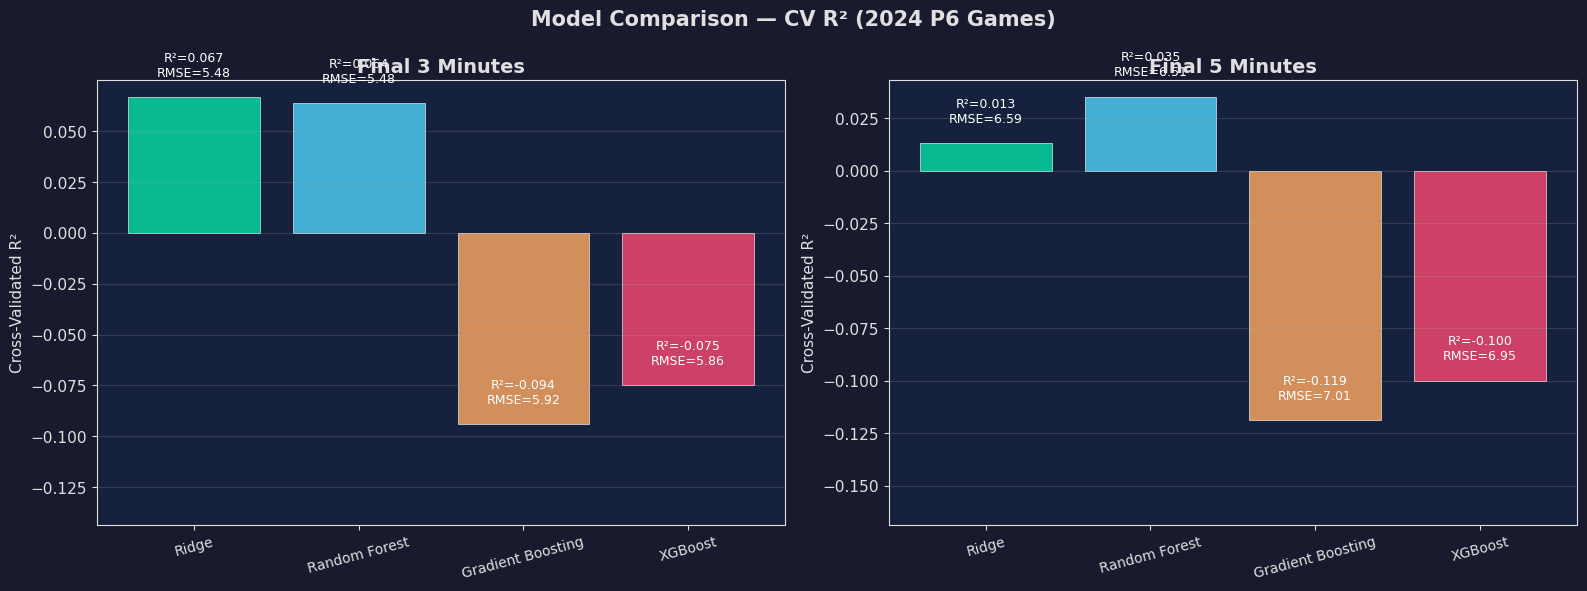

Saved: viz_model_comparison.png


In [9]:
# ── VIZ: Cross-validation comparison ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#06d6a0', '#4cc9f0', '#f4a261', '#ef476f']

for ax, results_df, title in [
    (axes[0], results_3, 'Final 3 Minutes'),
    (axes[1], results_5, 'Final 5 Minutes'),
]:
    models = results_df['Model'].values
    r2_vals = results_df['R2_mean'].values
    rmse_vals = results_df['RMSE_mean'].values
    
    x = np.arange(len(models))
    
    bars = ax.bar(x, r2_vals, color=colors[:len(models)], alpha=0.85,
                  edgecolor='white', linewidth=0.5)
    
    for i, (r2, rmse) in enumerate(zip(r2_vals, rmse_vals)):
        ax.text(i, r2 + 0.01, f'R²={r2:.3f}\nRMSE={rmse:.2f}',
                ha='center', fontsize=9, color='white')
    
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=10, rotation=15)
    ax.set_ylabel('Cross-Validated R²')
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='y', alpha=0.2)
    ax.set_ylim(bottom=min(0, min(r2_vals) - 0.05))

fig.suptitle(f'Model Comparison — CV R² ({SEASON} P6 Games)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'viz_model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_model_comparison.png')

---
## 6 — Feature Importance Analysis

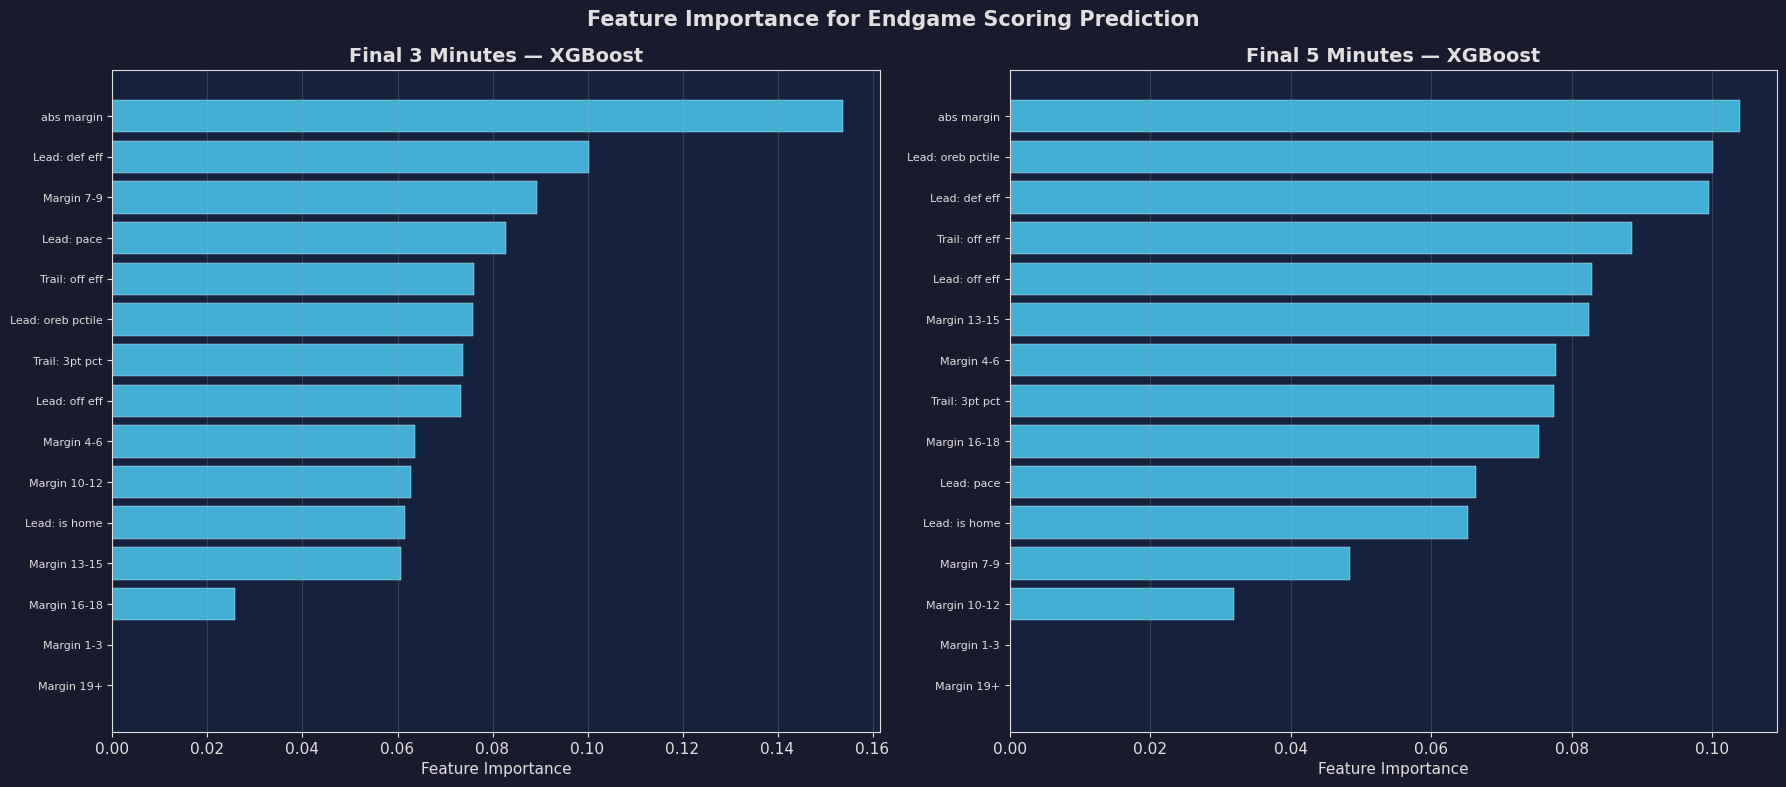

Saved: viz_feature_importance.png


In [10]:
# ── Feature importance from tree-based models ──
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, fitted, X_train, title in [
    (axes[0], fitted_3, X3_train, 'Final 3 Minutes'),
    (axes[1], fitted_5, X5_train, 'Final 5 Minutes'),
]:
    # Use Gradient Boosting or XGBoost importance
    if HAS_XGB and 'XGBoost' in fitted:
        model = fitted['XGBoost']
        model_name = 'XGBoost'
    else:
        model = fitted['Gradient Boosting']
        model_name = 'Gradient Boosting'
    
    importances = model.feature_importances_
    feature_names = X_train.columns
    
    sorted_idx = np.argsort(importances)
    
    # Clean up feature names for display
    display_names = []
    for n in feature_names[sorted_idx]:
        n = n.replace('lead_', 'Lead: ').replace('trail_', 'Trail: ')
        n = n.replace('avg_', '').replace('_', ' ').replace('bucket ', 'Margin ')
        display_names.append(n)
    
    ax.barh(range(len(sorted_idx)), importances[sorted_idx],
            color='#4cc9f0', alpha=0.85, edgecolor='white', linewidth=0.3)
    ax.set_yticks(range(len(sorted_idx)))
    ax.set_yticklabels(display_names, fontsize=8)
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'{title} — {model_name}', fontweight='bold')
    ax.grid(axis='x', alpha=0.2)

fig.suptitle('Feature Importance for Endgame Scoring Prediction',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'viz_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_feature_importance.png')

---
## 7 — Holdout Test Evaluation

Evaluate the best model(s) on the chronological holdout set.

In [11]:
def evaluate_on_test(fitted_models, X_test, y_test, label=''):
    """Evaluate all fitted models on the holdout test set."""
    results = []
    predictions = {}
    
    for name, model_or_tuple in fitted_models.items():
        if isinstance(model_or_tuple, tuple):
            model, scaler = model_or_tuple
            X_eval = scaler.transform(X_test)
        else:
            model = model_or_tuple
            X_eval = X_test
        
        y_pred = model.predict(X_eval)
        predictions[name] = y_pred
        
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        results.append({
            'Model': name,
            'Test RMSE': round(rmse, 3),
            'Test MAE': round(mae, 3),
            'Test R²': round(r2, 3),
        })
    
    return pd.DataFrame(results), predictions

print('=== 3-Minute Holdout Test Results ===')
test_results_3, preds_3 = evaluate_on_test(fitted_3, X3_test, y3_test, '3-min')
display(test_results_3)

print('\n=== 5-Minute Holdout Test Results ===')
test_results_5, preds_5 = evaluate_on_test(fitted_5, X5_test, y5_test, '5-min')
display(test_results_5)

=== 3-Minute Holdout Test Results ===


,Model,Test RMSE,Test MAE,Test R²
0,Ridge,6.021,4.505,0.128
1,Random Forest,5.928,4.517,0.154
2,Gradient Boosting,6.114,4.735,0.101
3,XGBoost,6.050,4.660,0.119



=== 5-Minute Holdout Test Results ===


,Model,Test RMSE,Test MAE,Test R²
0,Ridge,7.006,5.448,0.113
1,Random Forest,7.066,5.630,0.098
2,Gradient Boosting,7.323,5.905,0.031
3,XGBoost,7.211,5.781,0.061


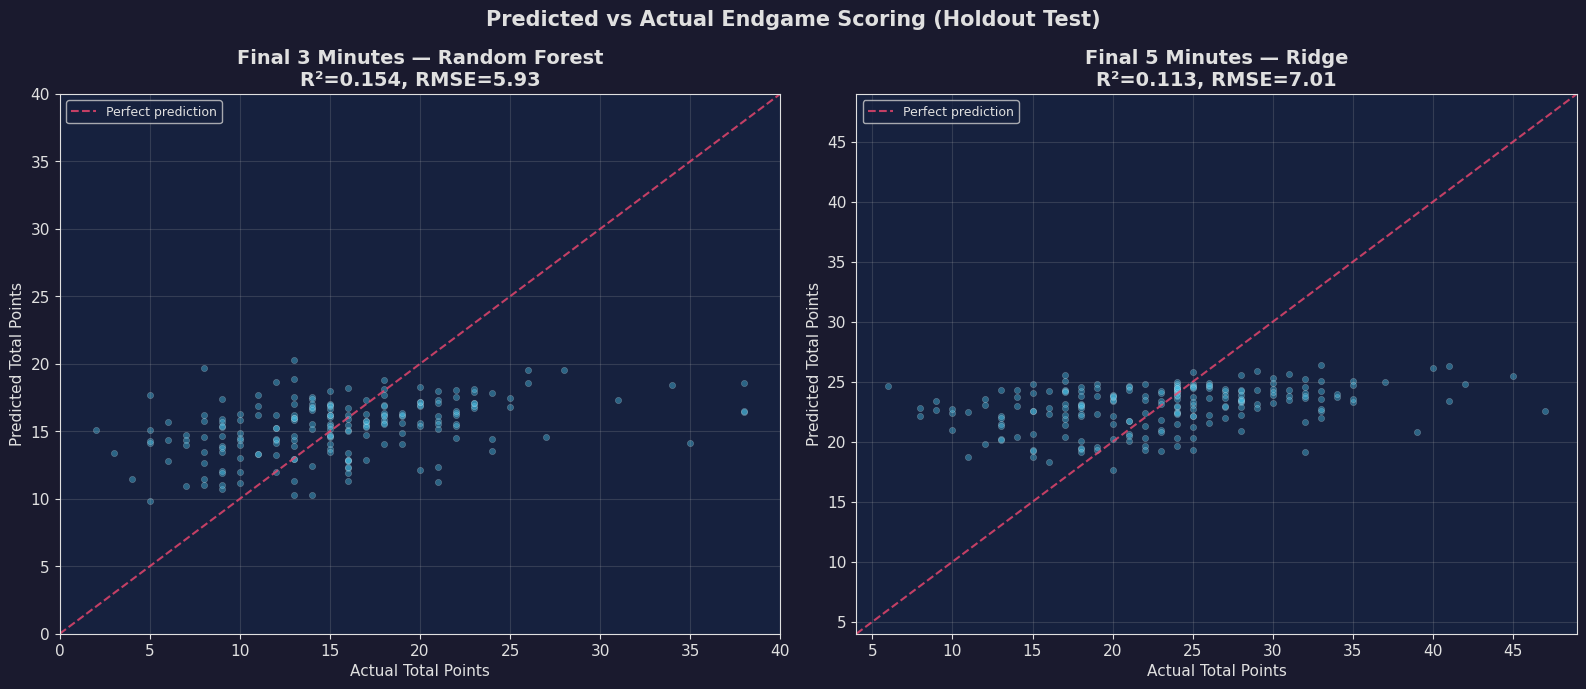

Saved: viz_pred_vs_actual.png


In [12]:
# ── VIZ: Predicted vs Actual (best model for each window) ──
def get_best_model_name(test_results_df):
    return test_results_df.loc[test_results_df['Test R²'].idxmax(), 'Model']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, test_results, preds, y_test, title, window_mins in [
    (axes[0], test_results_3, preds_3, y3_test, 'Final 3 Minutes', 3),
    (axes[1], test_results_5, preds_5, y5_test, 'Final 5 Minutes', 5),
]:
    best_name = get_best_model_name(test_results)
    y_pred = preds[best_name]
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    ax.scatter(y_test, y_pred, alpha=0.4, s=20, color='#4cc9f0', edgecolors='white', linewidths=0.3)
    
    # Perfect prediction line
    lims = [min(y_test.min(), y_pred.min()) - 2, max(y_test.max(), y_pred.max()) + 2]
    ax.plot(lims, lims, '--', color='#ef476f', alpha=0.8, linewidth=1.5, label='Perfect prediction')
    
    ax.set_xlabel('Actual Total Points')
    ax.set_ylabel('Predicted Total Points')
    ax.set_title(f'{title} — {best_name}\nR²={r2:.3f}, RMSE={rmse:.2f}', fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(alpha=0.2)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

fig.suptitle('Predicted vs Actual Endgame Scoring (Holdout Test)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'viz_pred_vs_actual.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_pred_vs_actual.png')

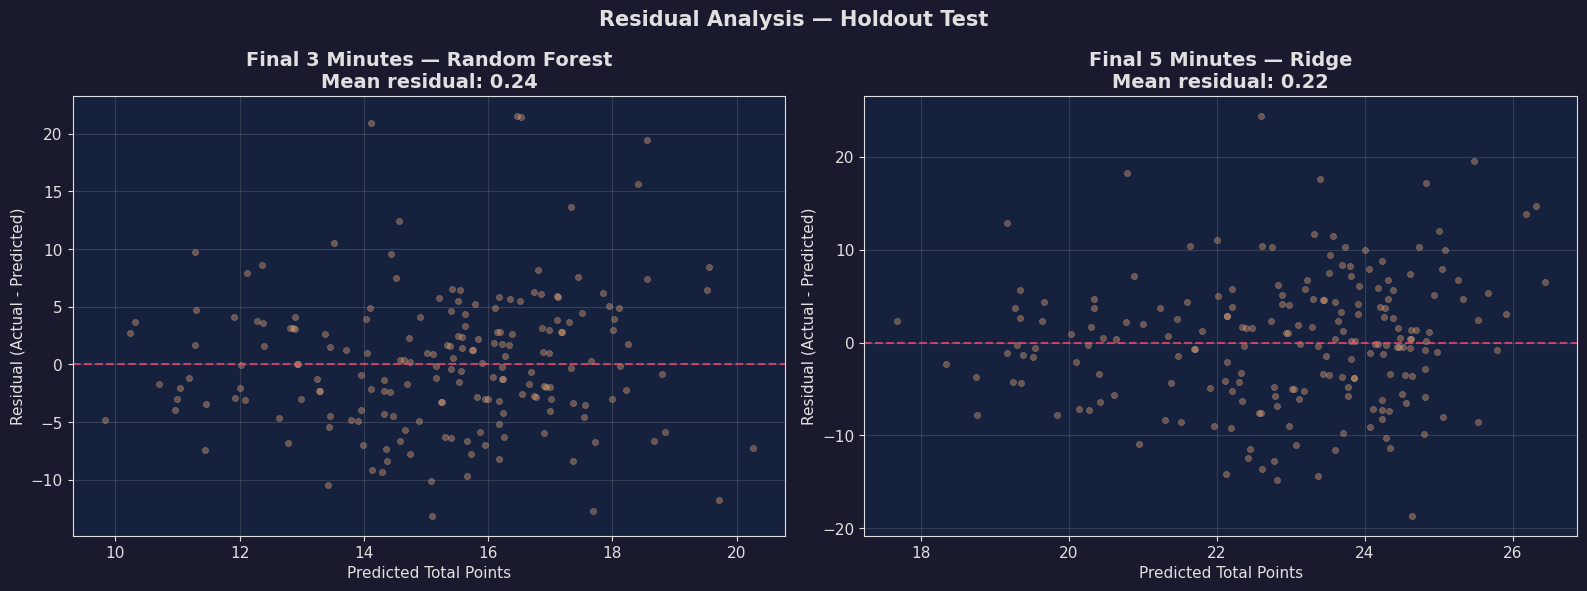

Saved: viz_residuals.png


In [13]:
# ── VIZ: Residual analysis ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, test_results, preds, y_test, df_test_idx, df_full, title in [
    (axes[0], test_results_3, preds_3, y3_test, test_idx_3, df_3, 'Final 3 Minutes'),
    (axes[1], test_results_5, preds_5, y5_test, test_idx_5, df_5, 'Final 5 Minutes'),
]:
    best_name = get_best_model_name(test_results)
    y_pred = preds[best_name]
    residuals = y_test - y_pred
    
    # Residuals by margin bucket
    buckets = df_full.loc[df_test_idx, 'fine_bucket'].values
    
    ax.scatter(y_pred, residuals, alpha=0.4, s=20, color='#f4a261', edgecolors='white', linewidths=0.3)
    ax.axhline(0, color='#ef476f', linestyle='--', alpha=0.8)
    ax.set_xlabel('Predicted Total Points')
    ax.set_ylabel('Residual (Actual - Predicted)')
    ax.set_title(f'{title} — {best_name}\nMean residual: {residuals.mean():.2f}',
                 fontweight='bold')
    ax.grid(alpha=0.2)

fig.suptitle('Residual Analysis — Holdout Test',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'viz_residuals.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_residuals.png')

---
## 8 — Real-Game Validation

Sample specific games from the holdout test set and show
predicted vs. actual scoring with game context.

In [14]:
def real_game_validation(df_full, test_idx, preds, test_results, X_test,
                          y_test, window_mins, n_games=20):
    """
    Show predicted vs actual for sample games.
    """
    best_name = get_best_model_name(test_results)
    y_pred = preds[best_name]
    
    test_df = df_full.loc[test_idx].copy()
    test_df['predicted_pts'] = np.round(y_pred, 1)
    test_df['actual_pts'] = y_test
    test_df['error'] = test_df['actual_pts'] - test_df['predicted_pts']
    test_df['abs_error'] = test_df['error'].abs()
    
    # Get team names from schedule
    home_names = schedule.set_index('game_id')['home_display_name'] if 'home_display_name' in schedule.columns else None
    away_names = schedule.set_index('game_id')['away_display_name'] if 'away_display_name' in schedule.columns else None
    
    # Sample: mix of good and bad predictions
    test_sorted = test_df.sort_values('abs_error')
    n_half = n_games // 2
    sample = pd.concat([test_sorted.head(n_half), test_sorted.tail(n_half)])
    
    display_cols = ['game_date', 'fine_bucket', 'abs_margin', 'lead_is_home',
                    'actual_pts', 'predicted_pts', 'error']
    
    result = sample[display_cols].copy()
    result['game_date'] = result['game_date'].dt.strftime('%Y-%m-%d')
    result = result.rename(columns={
        'fine_bucket': 'Margin Bucket',
        'abs_margin': 'Margin',
        'lead_is_home': 'Lead@Home',
        'actual_pts': 'Actual',
        'predicted_pts': 'Predicted',
        'error': 'Error',
        'game_date': 'Date',
    })
    
    return result

print(f'=== Real-Game Validation — Final 3 Minutes ===')
val_3 = real_game_validation(df_3, test_idx_3, preds_3, test_results_3,
                              X3_test, y3_test, 3)
display(val_3)

print(f'\n=== Real-Game Validation — Final 5 Minutes ===')
val_5 = real_game_validation(df_5, test_idx_5, preds_5, test_results_5,
                              X5_test, y5_test, 5)
display(val_5)

=== Real-Game Validation — Final 3 Minutes ===


,Date,Margin Bucket,Margin,Lead@Home,Actual,Predicted,Error
game_id,,,,,,,
401625446,2024-03-16,19+,30,0,12,12.0,0.0
401604236,2024-03-09,16-18,18,1,13,12.9,0.1
401625442,2024-03-14,16-18,18,1,13,12.9,0.1
401638624,2024-03-24,4-6,6,0,16,15.9,0.1
401625682,2024-03-14,10-12,10,0,18,18.1,-0.1
401625449,2024-03-14,7-9,7,0,15,15.2,-0.2
401597224,2024-03-06,13-15,14,1,16,16.2,-0.2
401599562,2024-03-06,7-9,8,1,18,17.7,0.3
401625565,2024-03-16,10-12,11,1,15,14.7,0.3



=== Real-Game Validation — Final 5 Minutes ===


,Date,Margin Bucket,Margin,Lead@Home,Actual,Predicted,Error
game_id,,,,,,,
401604230,2024-03-05,1-3,3,0,24,24.1,-0.1
401625686,2024-03-15,1-3,3,0,24,23.9,0.1
401625483,2024-03-16,1-3,2,0,23,23.1,-0.1
401600423,2024-03-05,4-6,4,0,24,24.2,-0.2
401599560,2024-03-06,10-12,10,1,24,23.8,0.2
401625409,2024-03-14,10-12,10,0,25,24.8,0.2
401604220,2024-03-02,19+,21,0,20,20.3,-0.3
401604224,2024-03-02,13-15,13,1,24,24.3,-0.3
401625444,2024-03-15,19+,24,1,19,19.3,-0.3


In [15]:
# ── Performance by margin bucket (holdout) ──
def bucket_performance(df_full, test_idx, preds, test_results, y_test, window_mins):
    best_name = get_best_model_name(test_results)
    y_pred = preds[best_name]
    
    test_df = df_full.loc[test_idx].copy()
    test_df['y_pred'] = y_pred
    test_df['y_true'] = y_test
    
    rows = []
    for bucket in FINE_LABELS:
        mask = test_df['fine_bucket'] == bucket
        if mask.sum() == 0:
            continue
        sub = test_df[mask]
        rmse = np.sqrt(mean_squared_error(sub['y_true'], sub['y_pred']))
        mae = mean_absolute_error(sub['y_true'], sub['y_pred'])
        r2 = r2_score(sub['y_true'], sub['y_pred']) if len(sub) > 1 else np.nan
        rows.append({
            'Margin Bucket': bucket,
            'Games': mask.sum(),
            'Avg Actual': round(sub['y_true'].mean(), 1),
            'Avg Predicted': round(sub['y_pred'].mean(), 1),
            'RMSE': round(rmse, 2),
            'MAE': round(mae, 2),
            'R²': round(r2, 3) if not np.isnan(r2) else np.nan,
        })
    return pd.DataFrame(rows)

print('=== Model Performance by Margin Bucket — 3-Minute (Holdout) ===')
bp_3 = bucket_performance(df_3, test_idx_3, preds_3, test_results_3, y3_test, 3)
display(bp_3)

print('\n=== Model Performance by Margin Bucket — 5-Minute (Holdout) ===')
bp_5 = bucket_performance(df_5, test_idx_5, preds_5, test_results_5, y5_test, 5)
display(bp_5)

=== Model Performance by Margin Bucket — 3-Minute (Holdout) ===


,Margin Bucket,Games,Avg Actual,Avg Predicted,RMSE,MAE,R²
0,1-3,27,14.8,15.7,5.39,4.22,0.008
1,4-6,26,18.4,16.1,5.94,4.90,-0.094
2,7-9,31,17.0,16.9,7.53,5.73,-0.001
3,10-12,26,16.9,16.8,5.60,4.19,0.138
4,13-15,26,15.7,15.4,6.35,4.70,0.197
5,16-18,19,13.2,13.9,3.82,3.18,0.228
6,19+,34,12.6,12.3,5.54,4.22,0.072



=== Model Performance by Margin Bucket — 5-Minute (Holdout) ===


,Margin Bucket,Games,Avg Actual,Avg Predicted,RMSE,MAE,R²
0,1-3,30,23.7,22.7,5.90,4.89,0.095
1,4-6,34,25.1,23.5,7.87,6.40,0.063
2,7-9,31,24.4,24.0,5.87,4.45,0.098
3,10-12,29,23.4,24.1,7.72,5.93,0.063
4,13-15,27,21.5,23.9,7.47,6.34,0.007
5,16-18,15,23.5,22.0,8.85,6.03,0.121
6,19+,34,20.5,20.2,5.92,4.52,0.078


---
## 9 — Summary

In [16]:
# ── Final Summary ──
best_3 = get_best_model_name(test_results_3)
best_5 = get_best_model_name(test_results_5)

r2_3 = test_results_3.loc[test_results_3['Model'] == best_3, 'Test R²'].values[0]
rmse_3 = test_results_3.loc[test_results_3['Model'] == best_3, 'Test RMSE'].values[0]
r2_5 = test_results_5.loc[test_results_5['Model'] == best_5, 'Test R²'].values[0]
rmse_5 = test_results_5.loc[test_results_5['Model'] == best_5, 'Test RMSE'].values[0]

print('='*60)
print(f'  PREDICTIVE MODEL SUMMARY — {SEASON} Season')
print('='*60)
print(f'\n  Data: P6 vs P6 games, non-tied at snapshot')
print(f'  Split: Chronological 80/20')
print(f'\n  Features ({len(X_3.columns)}):')
print(f'    1. Point differential (bucketed in 3s) — one-hot encoded')
print(f'    2. Adj. defensive efficiency (leading team)')
print(f'    3. Adj. offensive efficiency (leading & trailing teams)')
print(f'    4. Pace (leading team)')
print(f'    5. 3P% (trailing team)')
print(f'    6. ORB percentile (leading team)')
print(f'    7. Home/away status (leading team)')
print(f'    + Absolute margin (continuous)')
print(f'\n  Models evaluated: {len(fitted_3)}')
for name in fitted_3:
    print(f'    • {name}')
print(f'\n  === 3-Minute Window ===')
print(f'  Best model: {best_3}')
print(f'  Test R²: {r2_3} | Test RMSE: {rmse_3}')
print(f'  Train: {len(X3_train)} games | Test: {len(X3_test)} games')
print(f'\n  === 5-Minute Window ===')
print(f'  Best model: {best_5}')
print(f'  Test R²: {r2_5} | Test RMSE: {rmse_5}')
print(f'  Train: {len(X5_train)} games | Test: {len(X5_test)} games')
print(f'\n  Visualizations saved to data/:')
print(f'    • viz_model_comparison.png')
print(f'    • viz_feature_importance.png')
print(f'    • viz_pred_vs_actual.png')
print(f'    • viz_residuals.png')

  PREDICTIVE MODEL SUMMARY — 2024 Season

  Data: P6 vs P6 games, non-tied at snapshot
  Split: Chronological 80/20

  Features (15):
    1. Point differential (bucketed in 3s) — one-hot encoded
    2. Adj. defensive efficiency (leading team)
    3. Adj. offensive efficiency (leading & trailing teams)
    4. Pace (leading team)
    5. 3P% (trailing team)
    6. ORB percentile (leading team)
    7. Home/away status (leading team)
    + Absolute margin (continuous)

  Models evaluated: 4
    • Ridge
    • Random Forest
    • Gradient Boosting
    • XGBoost

  === 3-Minute Window ===
  Best model: Random Forest
  Test R²: 0.154 | Test RMSE: 5.928
  Train: 754 games | Test: 189 games

  === 5-Minute Window ===
  Best model: Ridge
  Test R²: 0.113 | Test RMSE: 7.006
  Train: 797 games | Test: 200 games

  Visualizations saved to data/:
    • viz_model_comparison.png
    • viz_feature_importance.png
    • viz_pred_vs_actual.png
    • viz_residuals.png
